# Testing Mediapipe Methods


# Attempt 2:

In [29]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
# from mediapipe.tasks.python.vision import drawing_utils
#from mediapipe.tasks.python.vision import drawing_styles
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

In [30]:
mp_drawing = mp.solutions.drawing_utils

from pathlib import Path

model_path = Path("face_landmarker.task")

print(model_path.resolve())
print(model_path.exists())

/Users/evedurant/Desktop/facemetric-api/models/face_landmarker.task
True


### Code adapted from MediaPipe Face Landmarker example:

In [31]:
# Create a FaceLandmarker object

# Code adapted from google Mediapipe Face Landmarker example:

# this dewscribes where the trained model is stored
base_options = python.BaseOptions(model_asset_path=str(model_path))

# this configures how the face landmarker should behave
options = vision.FaceLandmarkerOptions(base_options=base_options,
                                       output_face_blendshapes=True,
                                       output_facial_transformation_matrixes=True,
                                       num_faces=1)
# detector uses options from above
detector = vision.FaceLandmarker.create_from_options(options)



I0000 00:00:1786473323.614479 2567120 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 83), renderer: Apple M2
W0000 00:00:1786473323.625521 2567120 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.


## Key mediapipe indexes

In [32]:
FEATURES = {
    "left_eye_outer": 33,
    "left_eye_inner": 133,
    "right_eye_inner": 362,
    "right_eye_outer": 263,

    "nose_tip": 1,
    "nose_left": 98,
    "nose_right": 327,

    "mouth_left": 61,
    "mouth_right": 291,
    "upper_lip": 13,
    "lower_lip": 14,

    "upper_face": 10,
    "chin": 152,
    "left_cheek": 234,
    "right_cheek": 454,
}


## Get detection result

In [33]:
def get_detection_result_takes_path(img_path:str):
    """
    Takes in an image path and runs mediapipe on image.
    
    returns detection_result
        
    """
    # make image
    bgr_image = cv.imread(img_path)
        
    if bgr_image is None:
        raise FileNotFoundError( f"opencv cant read image")
        
    rgb_image = cv.cvtColor(
        bgr_image,
        cv.COLOR_BGR2RGB,
    )
        
    rgb_image = np.ascontiguousarray(
        rgb_image,
        dtype=np.uint8,
    )
        
    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=rgb_image, )
        
    # detect landmarks 
    detection_result = detector.detect(mp_image)
    return detection_result




def run_mediapipe_extract_symmetry_points(detection_result, img) -> np.ndarray:
    """
    Takes in an detection result and an image returns an x array and y array
    of points along the centre of the face
    """

    # finds the first (and only in this case) face detected by detection_result
    first_face = detection_result.face_landmarks[0]

    h, w = img.shape[:2]

    # the list of features that are meant to be in the centre of the face and 
    # their index with detection_result
    FEATURES = {"nose_tip": 1, "upper_lip": 13, "upper_face": 10, "chin": 152,}

    
    x = []
    y = []

    for feature_name, landmark_index in FEATURES.items():

        # each separate point in list of face landmarks
        landmark = first_face[landmark_index]

        pixel_x =  int(landmark.x * w)
        pixel_y = int(landmark.y * h)

        x.append(pixel_x)
        y.append(pixel_y)
        
    return x, y
        
def get_angle_of_rotation(img, x, y):
    """ Takes in an image and x and y arrays and 
    returns the angle the face makes iwth the vertical
    and the change in x that the rotation would create
    """
    height, _, _ = img.shape
    # this is the line of best fit that goes through the point in 
    # the x and y array in the form y = ax + b
    a, b = np.polyfit(x, y, 1)

    # now we find points x0, y0 where the line would cross the 
    # top of the image by rearranging y = ax+b to x = (y-b)/a
    # y0 is zero at the top of the image
    y0 = 0
    x0 = int((y0-b)/a)

    # here we find the point where this line would cross the bottom
    #  of the image, i.e the height for the y value
    y1 = height
    x1 = int((y1 - b)/a)

    # find change in x and chnage in y
    delta_x = x1 - x0
    delta_y = y1 - y0

    # find angle that the line of best fit makes with the vertical
    #  using trigonomatry
    theta = np.arctan(delta_x/delta_y)

    return theta, delta_x




    

theta in radians is -0.04234162507807369
 theta = -2.43 degrees
(5228, 3800, 3)


(np.float64(-0.5), np.float64(3799.5), np.float64(5227.5), np.float64(-0.5))

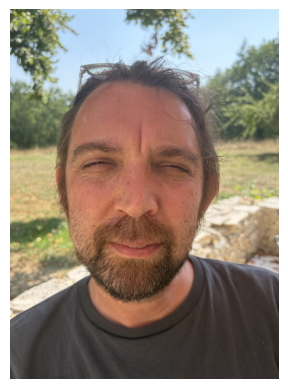

In [34]:
img_path = r'/Users/evedurant/Desktop/facemetric-api/tests/ben.jpeg'

def rotate_image(img, angle, delta_x) -> np.ndarray:
    """ rotates an image around its center and crops it by delta_x on all sides
    """
    h, w = img.shape[:2]
    centre = (w/2, h/2)

    rotation_matrix = cv.getRotationMatrix2D(center=centre,angle=-angle,scale=1.0,)

    rotated_img = cv.warpAffine(
        img,
        rotation_matrix,
        (w, h),
        flags=cv.INTER_LINEAR,
        borderMode=cv.BORDER_CONSTANT,
        borderValue=(0, 0, 0),
    )

    delta_x = abs(delta_x)

    cropped_img = rotated_img[delta_x:h - delta_x, delta_x: w - delta_x]
                                             

    return cropped_img


def rotate(img_path):
    """ Takes in an image path and returns a rotated image based
    on features of the face 
    """

    img = cv.imread(img_path)
    detection_result = get_detection_result_takes_path(img_path)
    x, y = run_mediapipe_extract_symmetry_points(detection_result, img)
    theta, delta_x = get_angle_of_rotation(img, x, y)
    print(f'theta in radians is {theta}')
    print(f" theta = {round(np.rad2deg(theta), 2)} degrees")
    cropped_img = rotate_image(img, theta, delta_x)
    cropped_img = cv.cvtColor(
            cropped_img,
            cv.COLOR_RGB2BGR)
    return cropped_img




#img = cv.imread(img_path)

# cv loads image in BGR but plt.imshow expects a RGB image
#img = cv.cvtColor(img, cv.COLOR_BGR2RGB)




rotated_img = rotate(img_path)

print(rotated_img.shape)
plt.imshow(rotated_img)
plt.axis('off')


[NormalizedLandmark(x=0.47279849648475647, y=0.6135176420211792, z=-0.05507379397749901, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4771820306777954, y=0.5452719926834106, z=-0.11868022382259369, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.47511690855026245, y=0.5596054792404175, z=-0.06037906929850578, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4583137333393097, y=0.48447731137275696, z=-0.09401123225688934, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.47807177901268005, y=0.5276323556900024, z=-0.1274811178445816, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4783736765384674, y=0.5033782720565796, z=-0.12048013508319855, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.47882089018821716, y=0.4440702199935913, z=-0.06587955355644226, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.32519614696502686, y=0.42882585525512695, z=0.020162876695394516, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4797915518283844, y=0.4044

list

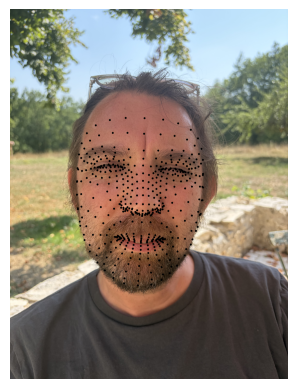

In [35]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/ben.jpeg"
img = cv.imread(img_path)
h, w, _ = img.shape
detection_result = get_detection_result_takes_path(img_path)
face = detection_result.face_landmarks[0]
print(face)

# convert to bgr
bgr_image = cv.cvtColor(
        img,
        cv.COLOR_RGB2BGR,
    )
for landmark in face:
    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv.circle(bgr_image, 
              (x, y),
              radius= 15,
              color=(0, 0, 0),
              thickness = -1,)


plt.imshow(bgr_image)
plt.axis('off')

type(face)


Rotation matrix code taken from Lyle Scott's Github

source: src="https://gist.github.com/LyleScott/e36e08bfb23b1f87af68c9051f985302.js"

In [54]:
xy = (9, 10)

def rotate_via_numpy(xy, radians):
    """
    Use numpy to build a rotation matrix and take the dot product.
    """
    x, y = xy
    c, s = np.cos(-radians), np.sin(-radians)
    j = np.matrix([[c, s], [-s, c]])
    m = np.dot(j, [x, y])
    return float(m.T[0].item()), float(m.T[1].item())

x, y = rotate_via_numpy(xy, 0.5)
print(x, y)

def rotate_all_landmarks():
    """
    takes in a FaceLandmarker object and updates each 
    point accoridng to the rotation matrix
    """
    

3.1039876709713248 13.090655466341556


theta in radians is -0.04234162507807369
 theta = -2.43 degrees


(np.float64(-0.5), np.float64(3799.5), np.float64(5227.5), np.float64(-0.5))

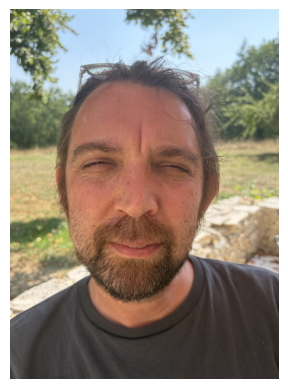

In [55]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/ben.jpeg"
img = cv.imread(img_path)
img_copy = img.copy()
radians = -0.0423416

for landmark in face:
    x = landmark.x
    y = landmark.y
    xy = (x, y)
    landmark.x, landmark.y = rotate_via_numpy(xy, radians)


rotated_img = rotate(img_path)
# bgr_image = cv.cvtColor(
#         img,
#         cv.COLOR_RGB2BGR,


#     )

# # convert to bgr
# bgr_image = cv.cvtColor(
#         img,
#         cv.COLOR_RGB2BGR,
#     )
for landmark in face:
    x = int(landmark.x * w)
    y = int(landmark.y * h)

    cv.circle(rotated_img, 
              (x, y),
              radius= 15,
              color=(0, 0, 0),
              thickness = -1,)




plt.imshow(rotated_img)
plt.axis('off')

In [42]:
# convert to bgr
bgr_image = cv.cvtColor(
        rotated_img,
        cv.COLOR_BGR2RGB,
    )

cv.imwrite("rotated_points.jpg", bgr_image)

True

While debugging with chatgpt, I realised that I am rotating the points around (0, 0) whilst rotating the image around the centre, leading to a mismatch.

It suggested I use the same matrix that i use to rotate the imagewhich i call in my rotation function : rotation_matrix = cv.getRotationMatrix2D(center=centre,angle=-angle,scale=1.0,) to rotate the points in facelandmarker.

And I also need to account for the amount that the image was cropped



/Users/evedurant/Desktop/facemetric-api/.venv/lib/python3.9/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


theta in radians is -0.04234162507807369
 theta = -2.43 degrees


(np.float64(-0.5), np.float64(3799.5), np.float64(5227.5), np.float64(-0.5))

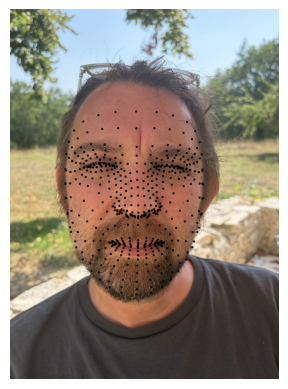

In [80]:
img_path = r"/Users/evedurant/Desktop/facemetric-api/tests/ben.jpeg"
img = cv.imread(img_path)
img_copy = img.copy()
img_copy = cv.cvtColor(
        img_copy,
        cv.COLOR_BGR2RGB,
    )

rotated_img = rotate(img_path)
detection_result = get_detection_result_takes_path(img_path)
face = detection_result.face_landmarks[0]

h, w, _ = img.shape
centre = (w/2, h/2)
x, y = run_mediapipe_extract_symmetry_points(detection_result, img)
theta, delta_x = get_angle_of_rotation(img, x, y)
theta = np.rad2deg(theta)
rotation_matrix = cv.getRotationMatrix2D(centre ,angle=-theta,scale=1.0,)

delta_x = abs(delta_x)

for landmark in face:
    x = landmark.x * w
    y = landmark.y * h

    # each point needs to be a 3d matrix since the opencv matrix has 3 columns
    point = np.array([x, y, 1.0])

    rotated_x, rotated_y = np.dot(rotation_matrix, point)

    rotated_x = rotated_x - delta_x
    rotated_y = rotated_y - delta_x

    landmark.x = float(rotated_x)
    landmark.y = float(rotated_y)

rotated_img = rotated_img.copy()
for landmark in face:
    x = int(landmark.x )
    y = int(landmark.y )

    cv.circle(rotated_img, 
              (x, y),
              radius= 15,
              color=(0, 0, 0),
              thickness = -1,)


plt.imshow(rotated_img)
plt.axis('off')

Now that the landmark rotation is working we can turn this into a funciton:

In [90]:
def rotate_landmarks(img_path):
    """ Takes in an img_path, detects key landmarks, detects
    the tilt of the face, theta, and rotates the facial landmarks
    by theta. Returns the rotated facial landmarks.
    """
    img = cv.imread(img_path)
    
    img = cv.cvtColor(
        img,
        cv.COLOR_BGR2RGB,
    )

    #rotated_img = rotate(img_path)
    detection_result = get_detection_result_takes_path(img_path)
    face = detection_result.face_landmarks[0]

    h, w, _ = img.shape
    centre = (w/2, h/2)
    x, y = run_mediapipe_extract_symmetry_points(detection_result, img)
    theta, delta_x = get_angle_of_rotation(img, x, y)
    theta = np.rad2deg(theta)
    rotation_matrix = cv.getRotationMatrix2D(centre ,angle=-theta,scale=1.0,)

    delta_x = abs(delta_x)

    for landmark in face:
        x = landmark.x * w
        y = landmark.y * h

        # each point needs to be a 3d matrix since the opencv matrix has 3 columns
        point = np.array([x, y, 1.0])

        rotated_x, rotated_y = np.dot(rotation_matrix, point)

        rotated_x = (rotated_x - delta_x)/w
        rotated_y = (rotated_y - delta_x)/h

        landmark.x = float(rotated_x)
        landmark.y = float(rotated_y)

    return face

In [91]:
face = rotate_landmarks(img_path)
print(face)

[NormalizedLandmark(x=0.42274039456823265, y=0.5719125112902745, z=-0.05507379397749901, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.42326830879055205, y=0.5035888657841718, z=-0.11868022382259369, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4220139999570875, y=0.5179750665049268, z=-0.06037906929850578, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.40098575390987456, y=0.44344767984297845, z=-0.09401123225688934, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.42316170267703823, y=0.48593679211478497, z=-0.1274811178445816, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4220944623053623, y=0.46169486249467817, z=-0.12048013508319855, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.419194009769813, y=0.40242576904774746, z=-0.06587955355644226, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.26484658510811676, y=0.3920721507891755, z=0.020162876695394516, visibility=0.0, presence=0.0), NormalizedLandmark(x=0.4179280570319991, y=0.362

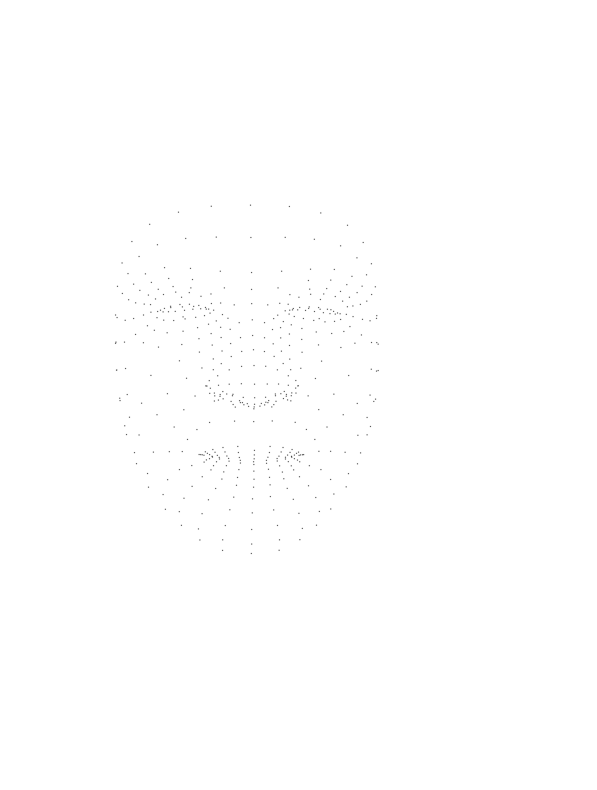

In [92]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt


def draw_landmarks_on_blank(face, width, height):
    """
    Draw MediaPipe landmarks on a blank white image.

    face:
        detection_result.face_landmarks[0]

    width, height:
        dimensions of the original image
    """

    # Create a white RGB image
    blank_img = np.ones(
        (height, width, 3),
        dtype=np.uint8
    ) * 255

    for landmark in face:

        # Normalized coordinates -> pixel coordinates
        x = int(landmark.x * width)
        y = int(landmark.y * height)

        cv.circle(
            blank_img,
            (x, y),
            radius=4,
            color=(0, 0, 0),
            thickness=-1,
        )

    return blank_img

img = cv.imread(img_path)

h, w = img.shape[:2]



blank_landmarks = draw_landmarks_on_blank(
    face,
    width=w,
    height=h,
)

plt.figure(figsize=(8, 10))
plt.imshow(blank_landmarks)
plt.axis("off")
plt.show()